In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
# 把 deeplearning 目录加入模块搜索路径
d2l_dir = Path(r"C:\Users\abc\Documents\GitHub\vscodepractice\deeplearning")
sys.path.insert(0, str(d2l_dir))
import math
import numpy as np
import torch
from torch import nn
import d2l_local as d2l

In [2]:
net = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5), nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [3]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [4]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size=batch_size)

In [5]:
def evaluate_accuracy_gpu(net, data_iter, device=None): #@save
    """使用GPU计算模型在数据集上的精度"""
    if isinstance(net, nn.Module):
        net.eval()  # 设置为评估模式，确保不会dropout，
        if not device:#自动找到模型所在的设备
            #iter(net.parameters())得到模型中的全部参数后将参数集合变成迭代器
            #next()函数返回迭代器的下一个元素，即模型的第一个参数
            #如果模型的参数在GPU上，则device为GPU，否则为CPU
            device = next(iter(net.parameters())).device
            
    # 正确预测的数量，总预测的数量
    metric = d2l.Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                # BERT微调所需的（之后将介绍）
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            ##y.numel() 返回标签数量，也就是这一批的样本数。
            metric.add(d2l.accuracy(net(X), y), y.numel())
            
    return metric[0] / metric[1]

In [ ]:
#@save
def train_ch6(net, train_iter, test_iter, num_epochs, lr, device):
    """用GPU训练模型(在第六章定义)"""
    def init_weights(m):# m表示模型中的某一层。
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)#就使用 Xavier 均匀分布初始化权重。
    net.apply(init_weights)#apply 会递归访问模型中的每一个子层，检查每一层的类型，满足要求就初始化
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # 训练损失之和，训练准确率之和，样本数
        metric = d2l.Accumulator(3)
        net.train()# 这会让 Dropout、BatchNorm 等层恢复训练行为。
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():# CrossEntropyLoss 默认返回一批样本的平均损失。乘以样本数可以得到损失之和。
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]#所有批次累计完成后再除以总样本数：
            train_acc = metric[1] / metric[2]#训练准确率：
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')

loss 0.466, train acc 0.824, test acc 0.793
48144.6 examples/sec on cuda:0


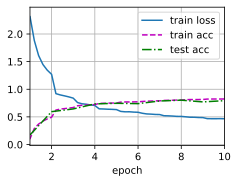

In [ ]:
lr, num_epochs = 0.9, 10
train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())

In [6]:
net1 = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5), nn.Sigmoid(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120), nn.Sigmoid(),
    nn.Linear(120, 84), nn.Sigmoid(),
    nn.Linear(84, 10))

In [7]:
def get_activations(net, image):
    # image原本是：(1, 28, 28)
    # 增加batch维度后：(1, 1, 28, 28)
    X = image.unsqueeze(0)

    device = next(net.parameters()).device
    X = X.to(device)

    net.eval()

    with torch.no_grad():
        # 第一卷积层和激活函数
        X = net[0](X)
        first_activation = net[1](X)

        # 第一次汇聚
        X = net[2](first_activation)

        # 第二卷积层和激活函数
        X = net[3](X)
        second_activation = net[4](X)

    return first_activation, second_activation

In [9]:
import matplotlib.pyplot as plt


def show_feature_maps(activation, title, max_maps=8):
    # 去掉batch维度
    feature_maps = activation[0].detach().cpu()

    number = min(
        max_maps,
        feature_maps.shape[0]
    )

    figure, axes = plt.subplots(
        1,
        number,
        figsize=(2 * number, 2)
    )

    for channel in range(number):
        axes[channel].imshow(
            feature_maps[channel],
            cmap="gray"
        )

        axes[channel].set_title(
            f"channel {channel}"
        )

        axes[channel].axis("off")

    figure.suptitle(title)
    plt.show()

In [12]:
def find_one_image(dataset, target_label):
    for image, label in dataset:
        if int(label) == target_label:
            return image

    raise ValueError("没有找到对应类别")

from torchvision import datasets
from torchvision import transforms


fashion_test = datasets.FashionMNIST(
    root="../data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)
# Fashion-MNIST中：
# 2表示Pullover（套头衫/毛衣）
# 4表示Coat（外套）
pullover = find_one_image(fashion_test, 2)
coat = find_one_image(fashion_test, 4)

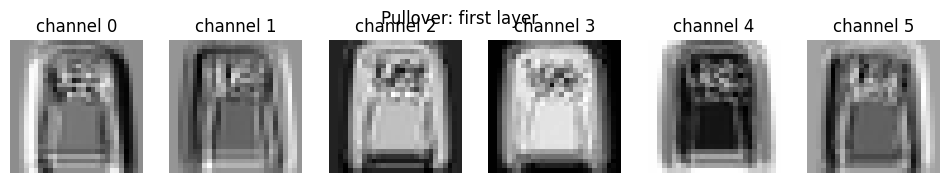

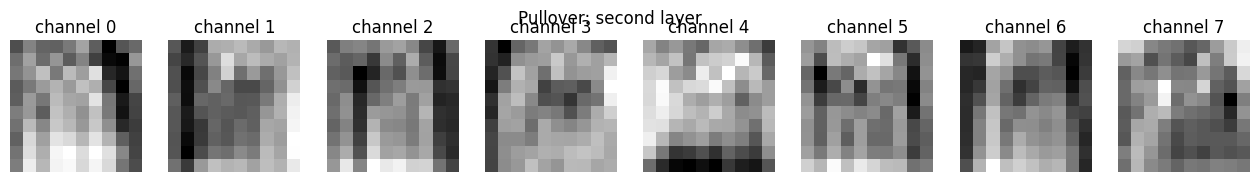

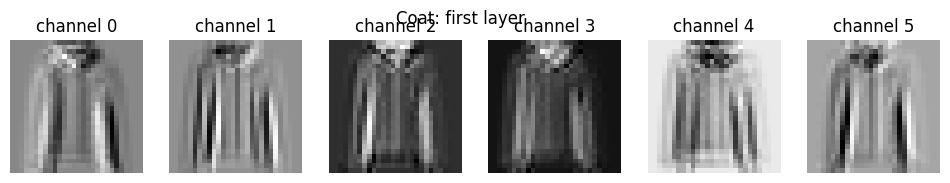

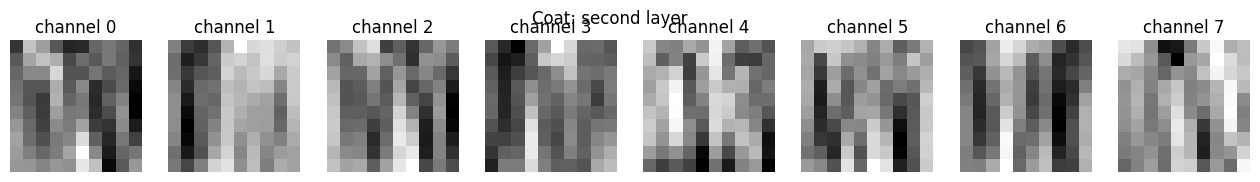

In [13]:
pullover_first, pullover_second = get_activations(
    net,
    pullover
)

coat_first, coat_second = get_activations(
    net,
    coat
)

show_feature_maps(
    pullover_first,
    "Pullover: first layer"
)

show_feature_maps(
    pullover_second,
    "Pullover: second layer"
)

show_feature_maps(
    coat_first,
    "Coat: first layer"
)

show_feature_maps(
    coat_second,
    "Coat: second layer"
)

In [14]:
print("原始输入：", pullover.unsqueeze(0).shape)
print("第一层激活：", pullover_first.shape)

原始输入： torch.Size([1, 1, 28, 28])
第一层激活： torch.Size([1, 6, 28, 28])


torch.Size([6, 1, 5, 5])


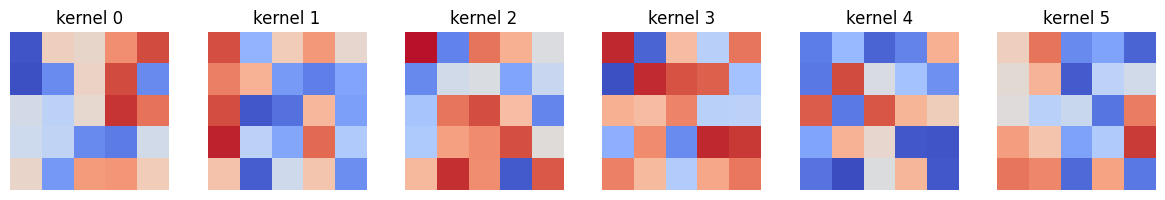

In [15]:
import matplotlib.pyplot as plt


kernels = net[0].weight.detach().cpu()

print(kernels.shape)  # (6, 1, 5, 5)

figure, axes = plt.subplots(
    1,
    6,
    figsize=(12, 2)
)

limit = kernels.abs().max().item()

for channel in range(6):
    kernel = kernels[channel, 0]

    axes[channel].imshow(
        kernel,
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit
    )

    axes[channel].set_title(
        f"kernel {channel}"
    )

    axes[channel].axis("off")

plt.tight_layout()
plt.show()